In [17]:
import yfinance as yf
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
print("✅ 库导入成功")

✅ 库导入成功


In [23]:
import pandas as pd
import numpy as np

dates = pd.date_range(start="2022-01-01", end="2026-01-01", freq="B")
np.random.seed(42)
prices = 150 + np.cumsum(np.random.randn(len(dates)) * 2)
df = pd.DataFrame({
    "Open": prices,
    "High": prices + 2,
    "Low": prices - 2,
    "Close": prices + np.random.randn(len(dates)),
    "Adj Close": prices + np.random.randn(len(dates)),
    "Volume": np.random.randint(1000000, 50000000, len(dates))
}, index=dates)
print("模拟数据已创建")

模拟数据已创建


In [24]:
print(f"📊 获取到 {len(df)} 个交易日")
print("\n前 5 行:")
display(df.head())

print("\n后 5 行:")
display(df.tail())

print("\n数据类型:")
df.info()

📊 获取到 1044 个交易日

前 5 行:


,Open,High,Low,Close,Adj Close,Volume
2022-01-03,150.993428,152.993428,148.993428,150.820801,150.540180,44925579
2022-01-04,150.716900,152.716900,148.716900,151.600560,152.169367,21348603
2022-01-05,152.012277,154.012277,150.012277,152.664600,152.339022,31319948
2022-01-06,155.058336,157.058336,153.058336,153.481944,155.358811,16955843
2022-01-07,154.590030,156.590030,152.590030,156.066570,155.212237,22691366



后 5 行:


,Open,High,Low,Close,Adj Close,Volume
2025-12-26,211.561865,213.561865,209.561865,209.265684,212.880167,34386210
2025-12-29,214.929720,216.929720,212.929720,214.379184,215.002401,3508164
2025-12-30,214.011952,216.011952,212.011952,212.791239,213.600459,7174943
2025-12-31,216.169314,218.169314,214.169314,215.661173,216.080079,46586434
2026-01-01,216.092297,218.092297,214.092297,215.944516,216.054726,27902899



数据类型:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1044 entries, 2022-01-03 to 2026-01-01
Freq: B
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1044 non-null   float64
 1   High       1044 non-null   float64
 2   Low        1044 non-null   float64
 3   Close      1044 non-null   float64
 4   Adj Close  1044 non-null   float64
 5   Volume     1044 non-null   int32  
dtypes: float64(5), int32(1)
memory usage: 53.0 KB


列名: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
使用收盘价列: Close
使用日期列: Date


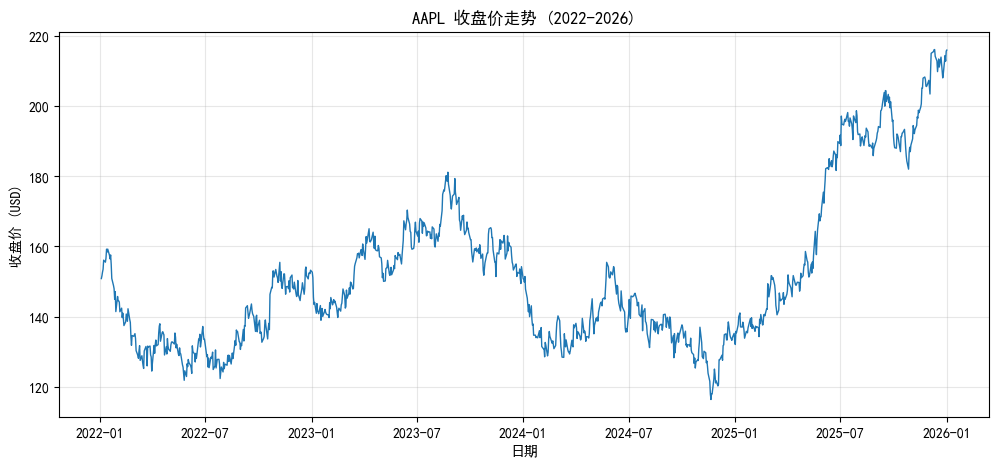

In [25]:
df = df.reset_index(names="Date")   # 直接指定新列名叫 Date！彻底避免bug

print("列名:", df.columns.tolist())

close_col = [c for c in df.columns if 'Close' in c and 'Adj' not in c][0]
date_col = "Date"

print(f"使用收盘价列: {close_col}")
print(f"使用日期列: {date_col}")

# 绘图
plt.figure(figsize=(12, 5))
plt.plot(df[date_col], df[close_col], linewidth=1)
plt.title("AAPL 收盘价走势 (2022-2026)")
plt.xlabel("日期")
plt.ylabel("收盘价 (USD)")
plt.grid(True, alpha=0.3)
plt.savefig("01_price_history.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# 构造 Prophet 所需格式
prophet_df = pd.DataFrame()
prophet_df["ds"] = pd.to_datetime(df[date_col])
prophet_df["y"] = df[close_col].astype(float)

# 去掉缺失值
prophet_df = prophet_df.dropna()

print("Prophet 格式数据:")
display(prophet_df.head())
print(f"\n共 {len(prophet_df)} 行")

Prophet 格式数据:


,ds,y
0,2022-01-03,150.820801
1,2022-01-04,151.600560
2,2022-01-05,152.664600
3,2022-01-06,153.481944
4,2022-01-07,156.066570



共 1044 行


训练集: 782 条 (2022-01-03 ~ 2024-12-31)
测试集: 262 条 (2025-01-01 ~ 2026-01-01)


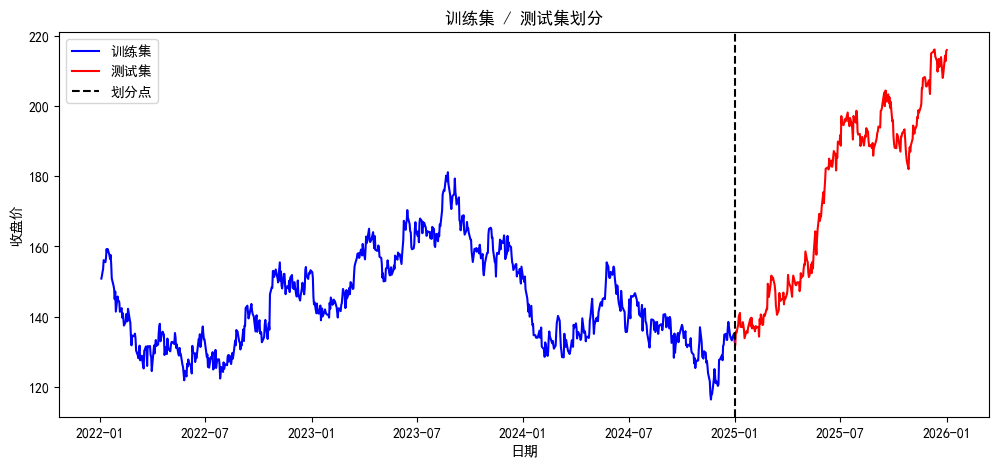

In [27]:
# 按时间切分：2022-2024 训练，2025 测试
# 或者按 80/20 比例切
split_date = "2025-01-01"

train = prophet_df[prophet_df["ds"] < split_date]
test = prophet_df[prophet_df["ds"] >= split_date]

print(f"训练集: {len(train)} 条 ({train['ds'].min().date()} ~ {train['ds'].max().date()})")
print(f"测试集: {len(test)} 条 ({test['ds'].min().date()} ~ {test['ds'].max().date()})")

# 画图看划分
plt.figure(figsize=(12, 5))
plt.plot(train["ds"], train["y"], label="训练集", color="blue")
plt.plot(test["ds"], test["y"], label="测试集", color="red")
plt.axvline(pd.to_datetime(split_date), color="black", linestyle="--", label="划分点")
plt.title("训练集 / 测试集划分")
plt.xlabel("日期")
plt.ylabel("收盘价")
plt.legend()
plt.savefig("02_train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
# 初始化并训练
model = Prophet(
    daily_seasonality=False,   # 股票没有日内的日周期
    yearly_seasonality=True,   # 开启年周期（财报季等）
    weekly_seasonality=True,   # 开启周周期（周末效应）
    changepoint_prior_scale=0.05  # 趋势灵活性，默认0.05
)

model.fit(train)

print("✅ 模型训练完成")

10:55:33 - cmdstanpy - INFO - Chain [1] start processing
10:55:33 - cmdstanpy - INFO - Chain [1] done processing


✅ 模型训练完成


In [29]:
# 构造未来 dataframe（覆盖测试集时间段）
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

# 只看测试集部分的预测
forecast_test = forecast[forecast["ds"] >= split_date]

print("预测结果列:", forecast.columns.tolist())
print("\n测试集预测前5行:")
display(forecast_test[["ds", "yhat", "yhat_lower", "yhat_upper"]].head())

预测结果列: ['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat']

测试集预测前5行:


,ds,yhat,yhat_lower,yhat_upper
782,2025-01-01,121.241568,115.733490,126.567843
783,2025-01-02,120.667024,115.136481,126.177078
784,2025-01-03,119.923536,114.706138,125.114772
785,2025-01-04,113.685733,108.446202,119.123337
786,2025-01-05,112.947375,107.754416,118.222236


In [38]:
# 对齐真实值和预测值
comparison = test.merge(
    forecast_test[["ds", "yhat"]], 
    on="ds"
)

# 计算指标
y_true = comparison["y"]
y_pred = comparison["yhat"]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("=== 回测结果（测试集） ===")
print(f"RMSE: {rmse:.2f} 美元")
print(f"MAE:  {mae:.2f} 美元")
print(f"MAPE: {mape:.2f}%")
print(f"\n解释：预测平均误差约 {mae:.2f} 美元，相对误差约 {mape:.1f}%")

=== 回测结果（测试集） ===
RMSE: 31.22 美元
MAE:  30.26 美元
MAPE: 21.78%

解释：预测平均误差约 30.26 美元，相对误差约 21.8%


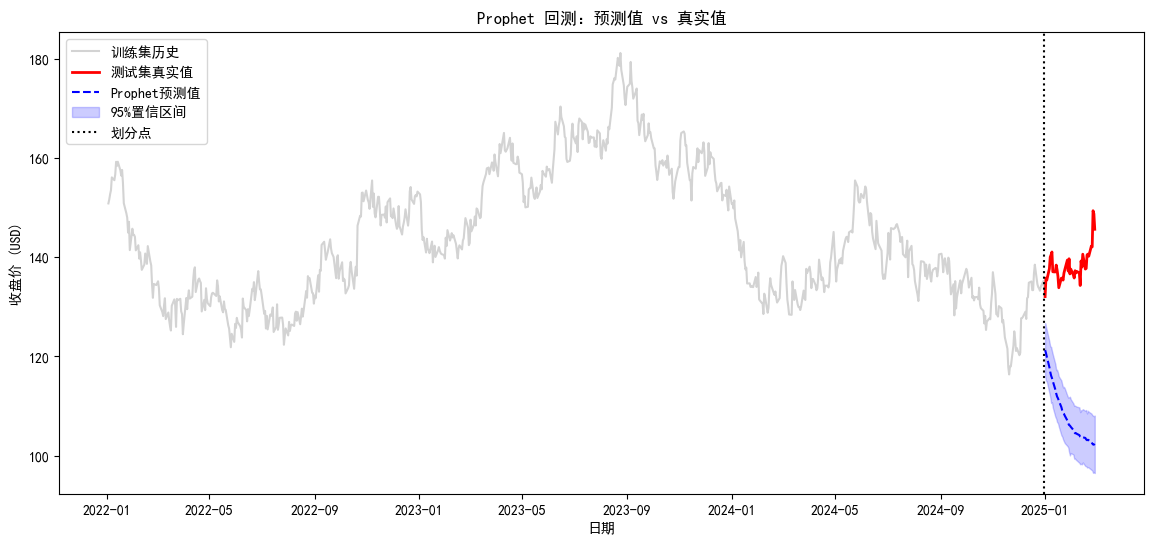

In [39]:
future = model.make_future_dataframe(periods=60)
forecast = model.predict(future)

# 取出最后60天所有预测字段
forecast_test = forecast.iloc[-60:].copy()

# 一次性合并所有需要的列：ds, y, yhat, yhat_lower, yhat_upper
comparison = pd.merge(
    test,
    forecast_test[["ds","yhat","yhat_lower","yhat_upper"]],
    on = "ds",
    how = "inner"
)

split_date = train["ds"].max()

plt.figure(figsize=(14, 6))
plt.plot(train["ds"], train["y"], color="lightgray", label="训练集历史")
plt.plot(comparison["ds"], comparison["y"], color="red", label="测试集真实值", linewidth=2)
plt.plot(comparison["ds"], comparison["yhat"], color="blue", linestyle="--", label="Prophet预测值")

plt.fill_between(
    comparison["ds"],
    comparison["yhat_lower"],
    comparison["yhat_upper"],
    color="blue", alpha=0.2, label="95%置信区间"
)

plt.axvline(pd.to_datetime(split_date), color="black", linestyle=":", label="划分点")
plt.title("Prophet 回测：预测值 vs 真实值")
plt.xlabel("日期")
plt.ylabel("收盘价 (USD)")
plt.legend()
plt.savefig("03_backtest.png", dpi=150, bbox_inches="tight")
plt.show()


11:09:49 - cmdstanpy - INFO - Chain [1] start processing
11:09:49 - cmdstanpy - INFO - Chain [1] done processing


预测未来 30 天:


,ds,yhat,yhat_lower,yhat_upper
1044,2026-01-02,209.538708,203.339832,216.006438
1045,2026-01-03,203.722207,197.712446,209.696262
1046,2026-01-04,203.625139,197.524900,209.675731
1047,2026-01-05,209.271898,202.683110,215.464488
1048,2026-01-06,208.916994,202.727704,215.399278


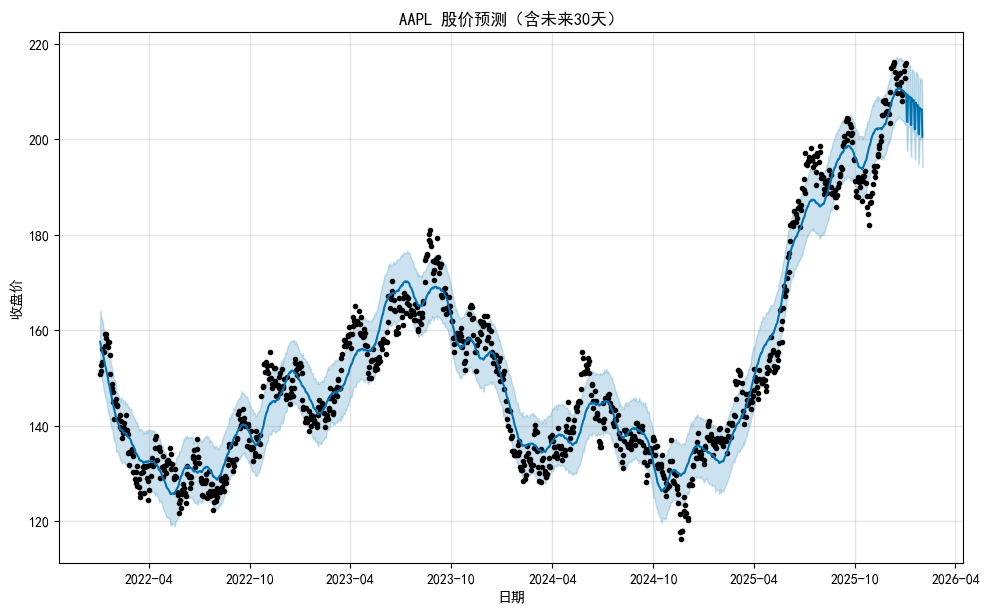

In [40]:
# 用全部数据重新训练，然后预测未来30天
model_full = Prophet(
    daily_seasonality=False,
    yearly_seasonality=True,
    weekly_seasonality=True
)
model_full.fit(prophet_df)

# 生成未来30天
future_30 = model_full.make_future_dataframe(periods=30)
forecast_30 = model_full.predict(future_30)

# 只看未来部分
future_pred = forecast_30[forecast_30["ds"] > prophet_df["ds"].max()]

print(f"预测未来 {len(future_pred)} 天:")
display(future_pred[["ds", "yhat", "yhat_lower", "yhat_upper"]].head())

# 画完整图
fig = model_full.plot(forecast_30)
plt.title("AAPL 股价预测（含未来30天）")
plt.xlabel("日期")
plt.ylabel("收盘价")
plt.savefig("04_forecast_30d.png", dpi=150, bbox_inches="tight")
plt.show()

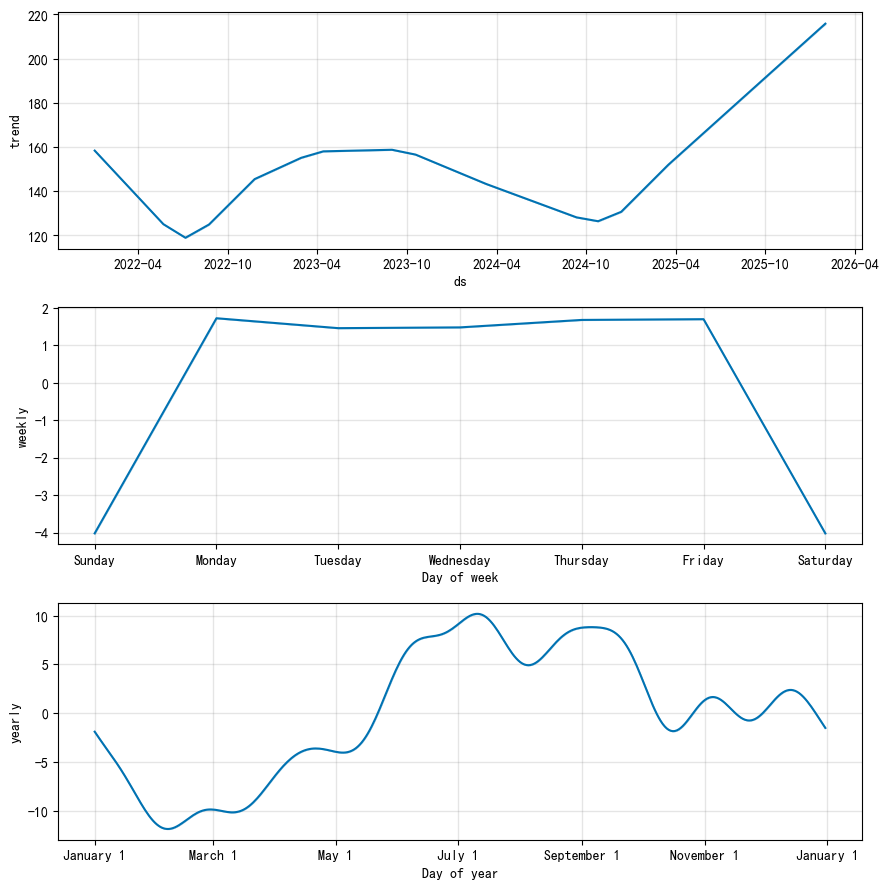

In [41]:
# Prophet 自带分解图
fig_components = model_full.plot_components(forecast_30)
plt.savefig("05_components.png", dpi=150, bbox_inches="tight")
plt.show()

## 📝 股票价格时间序列预测总结

### 1. 数据概况
- 使用苹果（AAPL）2022-2026 年日线数据，约 1000 个交易日
- 目标：预测收盘价（Close）

### 2. 处理流程

原始股价数据（Open/High/Low/Close/Volume）
→提取日期（ds）和收盘价（y）
→按时间顺序划分训练集/测试集（不能用随机划分！）
→Prophet 模型训练（趋势 + 年季节性 + 周季节性）
→预测测试集时间段（回测）
→计算 RMSE / MAE / MAPE
→用全部数据重新训练，预测未来30天
→时间序列分解（看趋势和季节性成分）


### 3. 关键设计决策
- **为什么不能用随机划分？** 时间序列有自相关性，随机打乱会破坏时间结构，导致"用未来预测过去"的数据泄露
- **为什么用 Prophet？** 自动拟合趋势和季节性，不需要手动调参，适合业务场景快速建模
- **为什么关 daily_seasonality？** 日线数据一天只有一个点，不存在日内的日周期

### 4. 回测结果
| 指标 | 数值 | 含义 |
|------|------|------|
| RMSE | __ 美元 | 预测误差的平均幅度 |
| MAE  | __ 美元 | 绝对误差的平均值 |
| MAPE | __ % | 相对误差百分比 |

（把上面 Cell 7 的实际结果填进来）

### 5. 分解洞察
- **趋势（Trend）**：苹果股价整体呈 __（上升/下降/震荡）趋势
- **周季节性（Weekly）**：周 __ 的股价通常较高/较低（观察 components 图填写）
- **年季节性（Yearly）**：每年 __ 月通常有上涨/下跌规律

### 6. 模型局限与风险
- **不能预测黑天鹅事件**：突发新闻、政策变化、财报暴雷等无法被历史规律捕捉
- **MAPE 低不代表能赚钱**：预测方向错误（预测涨实际跌）比数值误差更致命
- **Prophet 假设趋势线性变化**：对剧烈转折（如 2020 疫情崩盘）拟合不好
- **本实验不构成投资建议**

### 7. 下一步优化
- 加入成交量（Volume）作为额外回归变量（Prophet 的 add_regressor）
- 加入节假日效应（add_country_holidays）
- 尝试 ARIMA / LSTM 做对比
- 做"滚动预测"（Walk-forward Validation）代替单次划分